## Overview

In [21]:
import pandas
from datetime import datetime
from pytz import utc
import matplotlib.pyplot as plt
data = pandas.read_csv("reviews.csv", parse_dates=['Timestamp'])

In [2]:
data

,Course Name,Timestamp,Rating,Comment
0,The Python Mega Course: Build 10 Real World Ap...,2021-04-02 06:25:52+00:00,4.0,NaN
1,The Python Mega Course: Build 10 Real World Ap...,2021-04-02 05:12:34+00:00,4.0,NaN
2,The Python Mega Course: Build 10 Real World Ap...,2021-04-02 05:11:03+00:00,4.0,NaN
3,The Python Mega Course: Build 10 Real World Ap...,2021-04-02 03:33:24+00:00,5.0,NaN
4,The Python Mega Course: Build 10 Real World Ap...,2021-04-02 03:31:49+00:00,4.5,NaN
...,...,...,...,...
44995,Python for Beginners with Examples,2018-01-01 01:11:26+00:00,4.0,NaN
44996,The Python Mega Course: Build 10 Real World Ap...,2018-01-01 01:09:56+00:00,5.0,NaN
44997,The Python Mega Course: Build 10 Real World Ap...,2018-01-01 01:08:11+00:00,5.0,NaN
44998,Python for Beginners with Examples,2018-01-01 01:05:26+00:00,5.0,NaN


In [3]:
data.shape

(45000, 4)

## Subsetting

In [4]:
#Selecting Columns
data[['Course Name','Rating']]

,Course Name,Rating
0,The Python Mega Course: Build 10 Real World Ap...,4.0
1,The Python Mega Course: Build 10 Real World Ap...,4.0
2,The Python Mega Course: Build 10 Real World Ap...,4.0
3,The Python Mega Course: Build 10 Real World Ap...,5.0
4,The Python Mega Course: Build 10 Real World Ap...,4.5
...,...,...
44995,Python for Beginners with Examples,4.0
44996,The Python Mega Course: Build 10 Real World Ap...,5.0
44997,The Python Mega Course: Build 10 Real World Ap...,5.0
44998,Python for Beginners with Examples,5.0


In [5]:
#Selecting Rows
data.iloc[1:3]

Course Name    The Python Mega Course: Build 10 Real World Ap...
Timestamp                              2021-04-02 03:33:24+00:00
Rating                                                       5.0
Comment                                                      NaN
Name: 3, dtype: object

In [6]:
#Selecting Section
data[['Course Name','Rating']].iloc[1:3]

,Course Name,Rating
1,The Python Mega Course: Build 10 Real World Ap...,4.0
2,The Python Mega Course: Build 10 Real World Ap...,4.0


In [7]:
#Selecting Cell
data.at[2, 'Rating']

4.0

In [9]:
#Filtering Data on One Condition
data[data['Rating'] > 4].count() #len function also works

Course Name    29758
Timestamp      29758
Rating         29758
Comment         4927
dtype: int64

In [ ]:
#Filtering Data on multiple conditions
data[(data['Rating'] > 4) & (data['Course Name'] == "The Complete Python Course: Build 10 Professional OOP Apps")]

In [ ]:
data[(data['Timestamp'] >= datetime(2020, 7, 1, tzinfo=utc)) & (data['Timestamp'] <= datetime(2020, 12, 31, tzinfo=utc))]

### Rating average by day

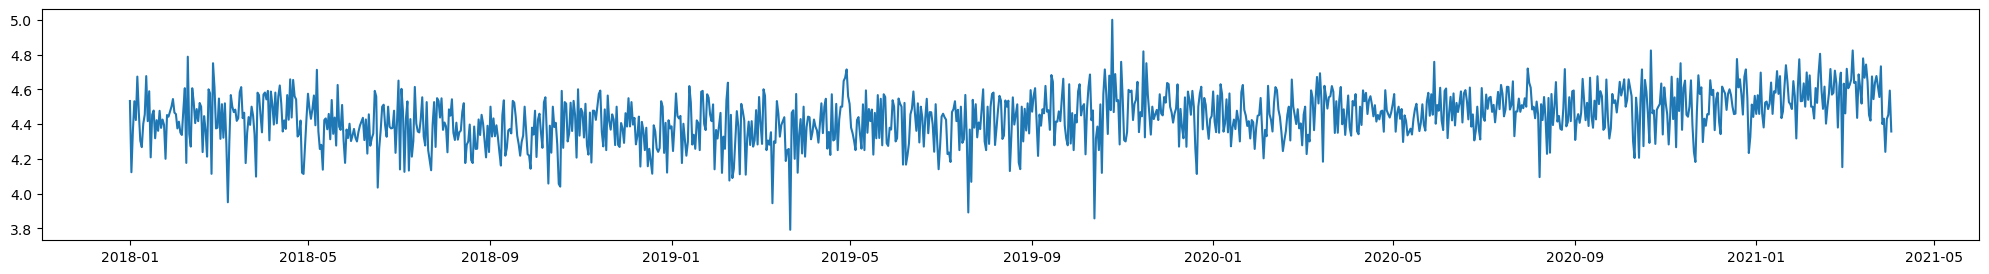

In [23]:
#Extract day from date
data['Day']=data['Timestamp'].dt.date
day_average = data.groupby(['Day']).mean()

plt.figure(figsize=(25, 3))
plt.plot(day_average.index, day_average['Rating'])

### Rating average by week and Month

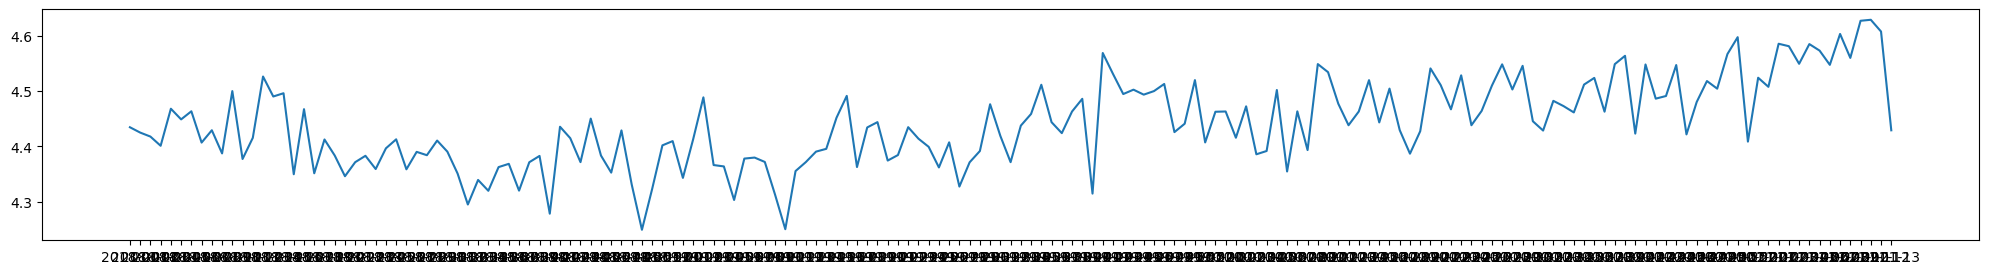

In [24]:
data['Week'] = data['Timestamp'].dt.strftime('%Y-%U')
week_average = data.groupby(['Week']).mean()

plt.figure(figsize=(25, 3))
plt.plot(week_average.index, week_average['Rating'])

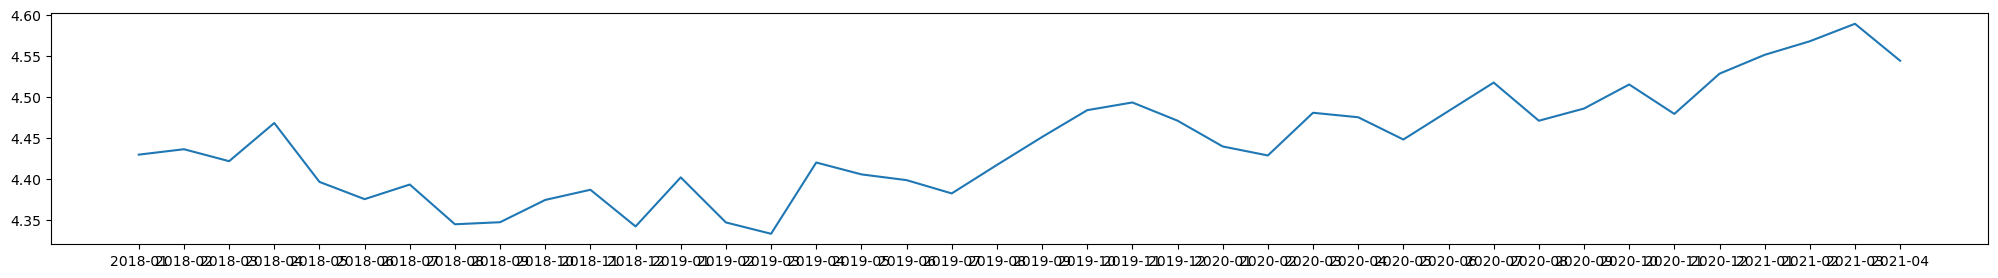

In [25]:
data['Month'] = data['Timestamp'].dt.strftime('%Y-%m')
month_average = data.groupby(['Month']).mean()

plt.figure(figsize=(25, 3))
plt.plot(month_average.index, month_average['Rating'])

### Average Rating by month and course

<AxesSubplot:xlabel='Month'>

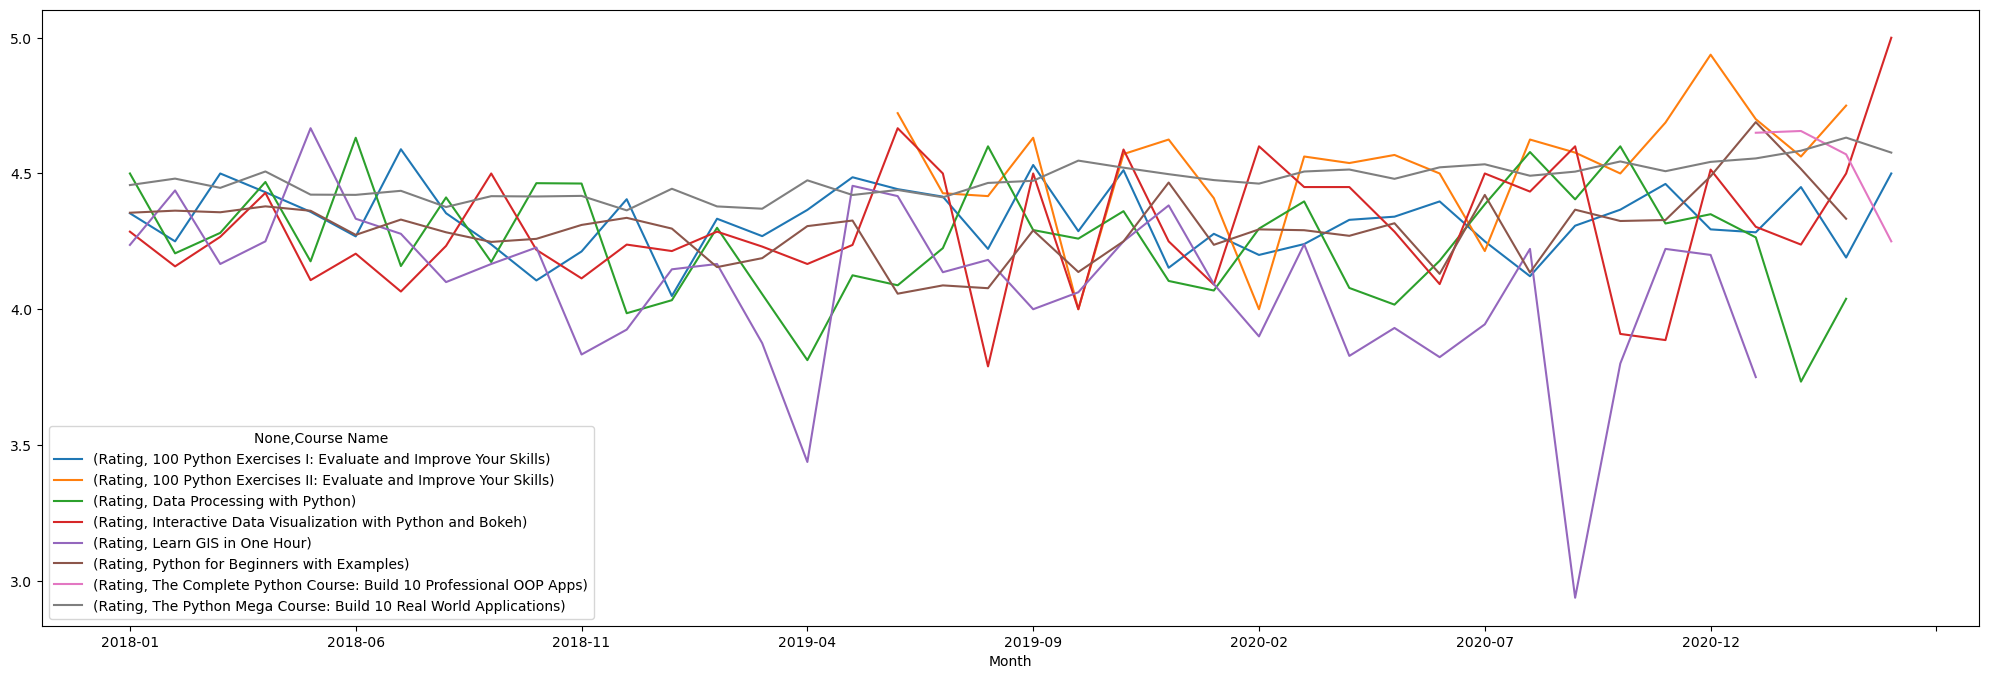

In [27]:
data['Month'] = data['Timestamp'].dt.strftime('%Y-%m')
month_average_crs = data.groupby(['Month', 'Course Name']).mean().unstack()
month_average_crs.plot(figsize=(25, 8))

### What Day are people the happiest

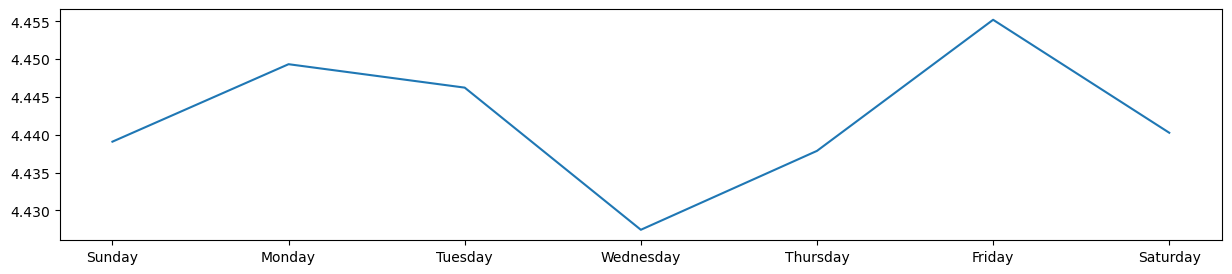

In [29]:
data['Weekday'] = data['Timestamp'].dt.strftime('%A')
data['Daynumber'] = data['Timestamp'].dt.strftime('%w')

weekday_average = data.groupby(['Weekday', 'Daynumber']).mean()
weekday_average = weekday_average.sort_values('Daynumber')

plt.figure(figsize=[15, 3])
plt.plot(weekday_average.index.get_level_values(0), weekday_average['Rating'])